**PROBLEME METIER**

Qui a besoin de ça ?
Agronomes, ONG, Ministère de l'agriculture du Togo

**Question métier**

Est-ce que la récolte sera bonne ou mauvaise cette année dans telle région ?

**Impact concret**
Anticiper les aides alimentaires, ajuster les subventions, planifier les semences

**Ce qu'on construit**
Modèle qui prédit si le rendement sera élevé ou faible (classification)

**Concepts compris aujourd'hui
Notions métier apprises en faisant**

**Rendement vs production:** 10 000 t sur 1 000 ha est plus efficace que 10 000 t sur 5 000 ha → le rendement mesure l'efficacité, pas la taille

**Normalisation:** Ramener des valeurs à une base comparable pour pouvoir comparer équitablement


In [2]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [3]:
import os

files = os.listdir("/content/drive/MyDrive/")
for f in files:
    print(f)

Screenshot_20250916-175220.jpg
Screenshot_20250916-175315.jpg
Screenshot_20250916-180629.jpg
Colab Notebooks
FAOSTAT_data_en_6-8-2026.csv


In [4]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/FAOSTAT_data_en_6-8-2026.csv")

print(df.shape)
df.head()

(64, 15)


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (FAO),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,768,Togo,5412,Yield,56,Maize (corn),1961,1961,kg/ha,492.6,E,Estimated value,NaN
1,QCL,Crops and livestock products,768,Togo,5412,Yield,56,Maize (corn),1962,1962,kg/ha,604.7,A,Official figure,NaN
2,QCL,Crops and livestock products,768,Togo,5412,Yield,56,Maize (corn),1963,1963,kg/ha,475.9,A,Official figure,NaN
3,QCL,Crops and livestock products,768,Togo,5412,Yield,56,Maize (corn),1964,1964,kg/ha,440.0,A,Official figure,NaN
4,QCL,Crops and livestock products,768,Togo,5412,Yield,56,Maize (corn),1965,1965,kg/ha,425.4,A,Official figure,NaN


**Création d'une nouvelle variable df_togo qui contient uniquement les colonnes Year et Value de ton DataFrame df puisque ce projet repose seulement sur le rendement de chaque annee**

In [5]:
df_togo=df[["Year","Value"]]

df_togo.head()

,Year,Value
0,1961,492.6
1,1962,604.7
2,1963,475.9
3,1964,440.0
4,1965,425.4


In [6]:
df_togo.tail()

,Year,Value
59,2020,1226.0
60,2021,1230.2
61,2022,1253.8
62,2023,1253.7
63,2024,1256.2


VERIFICATION DU DATASET AVANT DE NETOYER

In [7]:
df_togo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    64 non-null     int64  
 1   Value   64 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


Vocabulaire précis

— **moyenne, écart type, quartiles**.

 **Ce sont 4 quartiles** :

25% → 25% des valeurs sont en dessous de ce nombre

50% → la valeur du milieu (la médiane)

75% → 75% des valeurs sont en dessous

max → la valeur maximale

In [8]:
df_togo.describe()

,Year,Value
count,64.000000,64.000000
mean,1992.500000,1019.675000
std,18.618987,253.497209
min,1961.000000,425.400000
25%,1976.750000,897.300000
50%,1992.500000,1114.700000
75%,2008.250000,1215.850000
max,2024.000000,1389.500000


**Sur Year** — les années vont de 1961 à 2024. La moyenne est 1992.5 ce qui est logique — c'est exactement le milieu entre 1961 et 2024.

**Sur Value** — le rendement du maïs au Togo :
Statistique Valeur Ce que ça veut dire

 min 425 kg/ha Pire récolte — 1964

mean 1019 kg/ha Rendement moyen sur 64 ans

max 1389 kg/ha Meilleure récolte

std 253 kg/ha L'écart type

Question — l'écart type



Voici une explication simple :

La moyenne est 1019 kg/ha. L'écart type est 253 kg/ha.
Ça veut dire que la plupart des années, le rendement se situe entre :

1019 - 253 = 766 kg/ha

1019 + 253 = 1272 kg/ha

L'écart type mesure à quel point les valeurs s'éloignent de la moyenne. Un écart type élevé = données très dispersées. Un écart type faible = données concentrées autour de la moyenne.


**Un graphique en courbe**  
 est idéal quand on montre une évolution continue dans le temps. Les points sont connectés parce que les données sont liées — 1962 vient après 1961, 1963 vient après 1962. La courbe montre la tendance, les hausses, les baisses.


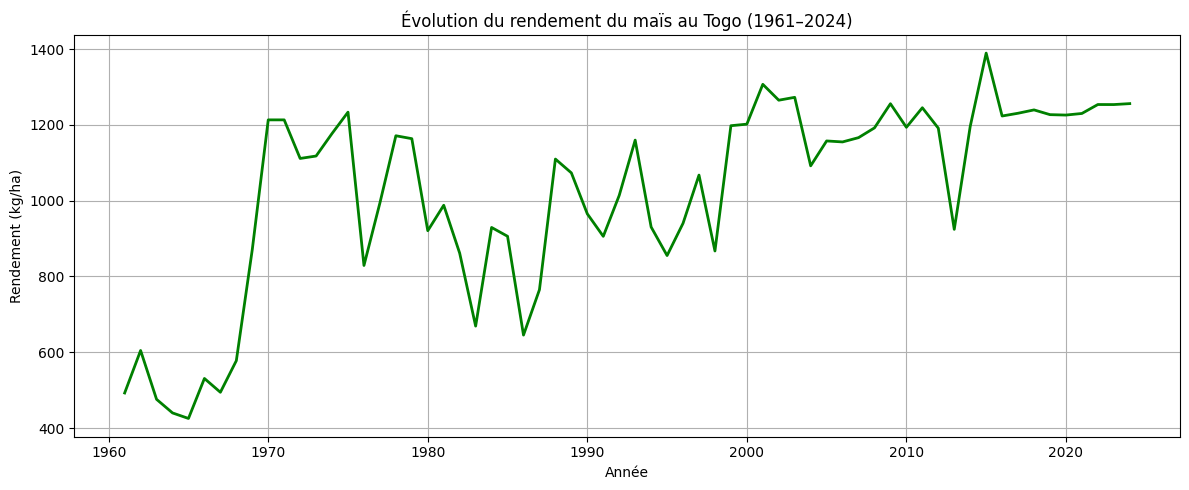

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(df_togo["Year"], df_togo["Value"], color="green", linewidth=2)

plt.title("Évolution du rendement du maïs au Togo (1961–2024)")
plt.xlabel("Année")
plt.ylabel("Rendement (kg/ha)")

plt.grid(True)
plt.tight_layout()
plt.show()

**Sur 1970-1975** — "évolution brusque puis chute brusque". C'est exact. En data science il s'agit un pic — une hausse soudaine suivie d'une baisse. Ce pic correspond à l'introduction des premières politiques agricoles modernes au Togo après l'indépendance.

**Sur 2000-2024** —  Il y a des hauts et des bas mais la tendance générale monte. Il s'agit une **tendance haussière avec volatilité**. Le rendement progresse globalement mais avec des fluctuations chaque année dues aux aléas climatiques.

Le graphique est bien mais on peut l'améliorer pour montrer clairement la direction générale au-delà des fluctuations annuelles.

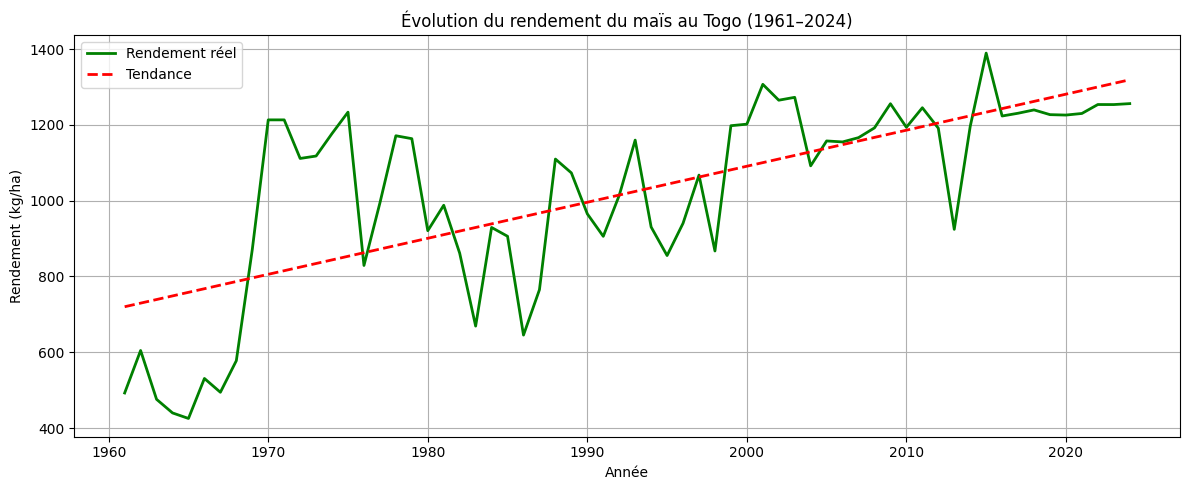

In [10]:
import numpy as np

z = np.polyfit(df_togo["Year"], df_togo["Value"], 1)
p = np.poly1d(z)

plt.figure(figsize=(12, 5))
plt.plot(df_togo["Year"], df_togo["Value"],
         color="green", linewidth=2, label="Rendement réel")
plt.plot(df_togo["Year"], p(df_togo["Year"]),
         color="red", linewidth=2, linestyle="--", label="Tendance")
plt.title("Évolution du rendement du maïs au Togo (1961–2024)")
plt.xlabel("Année")
plt.ylabel("Rendement (kg/ha)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**np.polyfit()**

calcule mathématiquement la droite qui passe le mieux à travers tous les points. C'est ce qu'on appelle **regression lineaire**

## Analyse de la tendance

La courbe de tendance montre une progression générale du rendement
du maïs au Togo sur 64 ans. Si cette tendance se maintient,
une hausse progressive est probable dans les 10 prochaines années.
Cependant, des facteurs externes comme le changement climatique
ou les politiques agricoles pourraient modifier cette trajectoire.
Un modèle de machine learning permettra de quantifier cette prédiction.

**Entraîner un modele**= montrer au modèle une partie(80%) des données avec les réponses correctes pour qu'il apprenne les patterns.

**Tester un modele** = lui donner des(20%) données qu'il n'a jamais vues et vérifier si ses prédictions sont correctes.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df_togo[["Year"]]
y = df_togo["Value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Entraînement : {len(X_train)} années")
print(f"Test : {len(X_test)} années")

Entraînement : 51 années
Test : 13 années


Maintenant on entraîne le modèle.

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Coefficient : {model.coef_[0]:.2f}")
print(f"Intercept : {model.intercept_:.2f}")

Coefficient : 10.01
Intercept : -18923.79


**Coefficient : 10.01**

Ça veut dire que chaque année qui passe, le rendement augmente en moyenne de 10 kg/ha. C'est la pente de la droite rouge que tu as vue sur ton graphique.

**Intercept : -18923.79**

C'est la valeur théorique du rendement en l'an 0. C'est un chiffre négatif et absurde — évidemment le maïs n'existait pas en l'an 0. C'est juste un paramètre mathématique, pas une valeur réelle.

**La formule de ton modèle est donc :**

Rendement = (10.01 × Année) - 18923.79= ..

Rendement = (10.01 × 2004) - 18923.79=1336.45

or que d'apres ce qui precede en 2024 value=1256

Le modèle a surestimé de 80 kg/ha. Ce n'est pas parfait

Pourquoi cette différence ?

l'année seule ne suffit pas pour prédire parfaitement. Des facteurs comme la pluviométrie ou les engrais créent des fluctuations que notre modèle ne peut pas capturer.
Cette différence entre la valeur prédite et la valeur réelle s'appelle une **erreur de prédiction** ou **résidu**.

Maintenant on mesure officiellement la précision du modèle.

In [13]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erreur moyenne absolue (MAE) : {mae:.2f} kg/ha")
print(f"Score R² : {r2:.2f}")

Erreur moyenne absolue (MAE) : 173.92 kg/ha
Score R² : 0.36


**MAE : 173.92 kg/ha**

Le modèle se trompe en moyenne de 174 kg/ha sur ses prédictions. Sur un rendement moyen de 1019 kg/ha, c'est une erreur d'environ 17%. Pas excellent .

**R² : 0.36**

C'est le chiffre le plus important. Il se lit comme un pourcentage :

R² = 1.0 → modèle parfait, 100% des variations expliquées

R² = 0.36 → le modèle explique seulement 36% des variations du rendement

R² = 0.0 → le modèle n'explique rien

0.36 c'est faible. Ça confirme ce qu'on avait dit — l'année seule ne suffit pas. Les 64% restants sont expliqués par des facteurs qu'on n'a pas dans nos données : pluie, engrais, politiques agricoles.


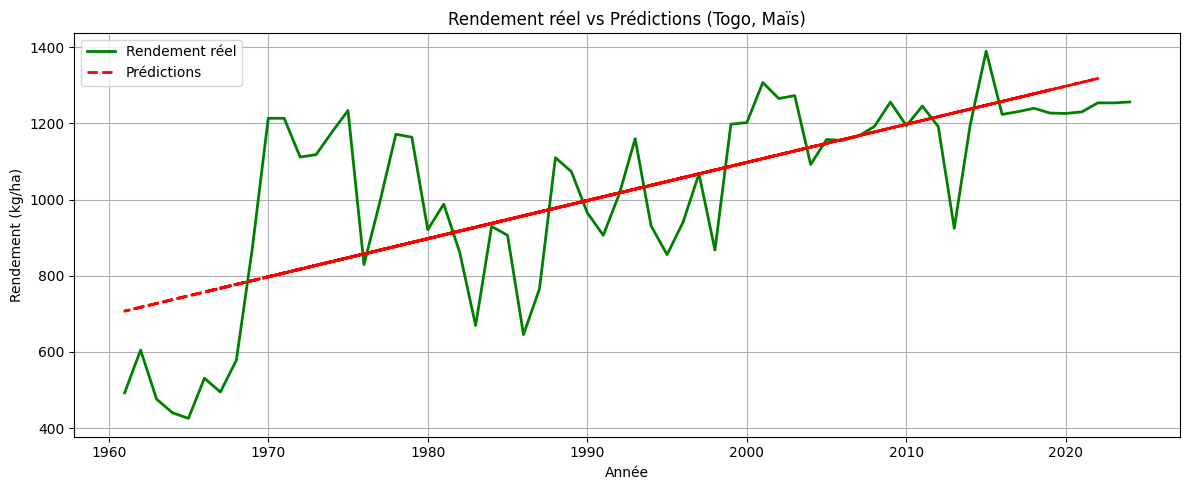

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(df_togo["Year"], df_togo["Value"],
         color="green", linewidth=2, label="Rendement réel")
plt.plot(X_test, y_pred,
         color="red", linewidth=2,
         linestyle="--", label="Prédictions")
plt.title("Rendement réel vs Prédictions (Togo, Maïs)")
plt.xlabel("Année")
plt.ylabel("Rendement (kg/ha)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Résultats et conclusions

Ce projet analyse l'évolution du rendement du maïs au Togo
de 1961 à 2024, à partir des données officielles de la FAO.
L'objectif était de construire un modèle capable de prédire
le rendement annuel en kg/ha.

## Performance du modèle

Le modèle de régression linéaire obtient :
- MAE : 173.92 kg/ha (erreur moyenne de prédiction)
- R² : 0.36 (le modèle explique 36% des variations du rendement)

## Limites

Le R² faible s'explique par le fait que l'année seule
ne suffit pas à prédire le rendement agricole. Des facteurs
importants sont absents du modèle : pluviométrie, utilisation
d'engrais, politiques agricoles du gouvernement togolais,
et conditions climatiques.

## Améliorations possibles

Pour améliorer ce modèle, il faudrait intégrer :
1. Les données météorologiques annuelles du Togo
2. Les données d'utilisation d'engrais par région
3. Les indicateurs de politique agricole nationale
Un modèle Random Forest avec ces variables supplémentaires
donnerait un R² significativement plus élevé.